# Total precipitation statistical comparisons

This notebook will calculate the statistical metrics and produce Taylor diagrams for all precipitation gauges included in this analysis.

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils.helper_funcs import TaylorDiagram, INSTRUMENT_PLOT_DICT 

## Data

In [5]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/")
TABLE_OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/tables/")
GRIDDED_VARS = ['ERA5-Land','PRISM','billy_barr_precip']

## Functions

### Get datasets

In [6]:
def get_dataset(site, directory, time_slice=None):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min_with_flags.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    # merge datasets
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    if time_slice is not None:
        ds = ds.sel(time=time_slice)
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

### Get relevant dates

In [7]:
def get_relevant_dates(ds, analysis_type, water_year=None, gridded=False):
    
    """Get the relevant start and end dates for analysis based on data availability.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        analysis_type (str): Type of analysis ('all', 'rain', 'snow', DJFM).
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
    """
    # for each datavar, get the time series of the first and last non-nan values
    starts = []
    ends = []
    for var in ds.data_vars:
        data = ds[var]
        first_valid_index = data.to_series().first_valid_index()
        last_valid_index = data.to_series().last_valid_index()
        starts.append((var, first_valid_index))
        ends.append((var, last_valid_index))

    # find the latest start time and the earliest end time after June 1, 2023
    if (analysis_type == 'all' and water_year is None) or (gridded and analysis_type == 'all'):
    
        latest_start = max(start[1] for start in starts if start[1] <= pd.Timestamp("2021-10-01"))
    
        if gridded:
            earliest_end = min(end[1] for end in ends if end[1] >= pd.Timestamp("2023-09-30"))
        else:
            earliest_end = pd.Timestamp("2023-06-12")
    elif analysis_type == 'rain':
        if water_year is None:
            raise ValueError("water_year must be specified for rain season analysis.")
        latest_start = pd.Timestamp(f"{water_year}-06-01") ### rain season starts May 1 of previous calendar year
        earliest_end = pd.Timestamp(f"{water_year}-09-30")
    elif analysis_type == 'snow':
        if water_year is None:
            raise ValueError("water_year must be specified for snow season analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-05-31")
    elif analysis_type == 'DJFM':
        if water_year is None:
            raise ValueError("water_year must be specified for DJFM analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-12-01")
        earliest_end = pd.Timestamp(f"{water_year}-03-31")
    elif analysis_type == 'all' and water_year == 2022:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-09-30")
    elif analysis_type == 'all' and water_year == 2023:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-06-12")
    else:
        raise ValueError("Invalid combination of analysis_type and water_year. Only 2022 and 2023 water years are supported for seasonal analyses.")
    return slice(latest_start, earliest_end)

### Drop bad vars

In [8]:
def drop_bad_or_irrelevant_vars(ds, nan_threshold=0.8):
    """Drop variables with known data quality issues or irrelevant to the analysis."""
    bad_vars = ['sail_pwd_rain', 'sail_squire_rain','sail_tbg_corr', 'rain_rate_A']  # example bad vars
    gridded_vars = ['ERA5-Land','PRISM']  # keep these regardless of nans
    for var in ds.data_vars:
        if var in ds.data_vars:
            if var in bad_vars:
                ds = ds.drop_vars(var)
            elif var in gridded_vars:
                continue  # keep gridded vars
            else:
                # calculate number of nans in variable
                nan_count = ds[var].isnull().sum().item()
                if (nan_count / ds.sizes['time']) > nan_threshold:  # if more than 80% nans, drop variable
                    ds = ds.drop_vars(var)
        else:
            continue
    return ds

### Calculate bias metrics

In [9]:
def calc_bias_metrics(full_ds, benchmark, water_year, analysis_type, nan_threshold=0.8, gridded_vars=GRIDDED_VARS):
    # Select relevant time slice and clean dataset
    time_slice = get_relevant_dates(full_ds, analysis_type=analysis_type, water_year=water_year, gridded=False)
    ds = drop_bad_or_irrelevant_vars(full_ds.sel(time=time_slice), nan_threshold=nan_threshold)
    ds = ds.resample(time='1D', offset='8h').sum()
    
    if gridded_vars is not None:
        time_slice = get_relevant_dates(full_ds, analysis_type=analysis_type, water_year=water_year, gridded=True)
        gridded_ds = full_ds[gridded_vars].sel(time=time_slice).resample(time='1D', offset='8h').sum()

    # calculate bias dataset
    var_to_mask = []
    
    normalized_bias = (ds - ds[benchmark]).sum()/(ds[benchmark].sum())
    mean_absolute_error = np.mean(np.abs(ds - ds[benchmark]))
    fractional_bias = (2*(ds - ds[benchmark]).sum()) / (ds.sum() + ds[benchmark].sum())
    norm_rmse = np.sqrt(((ds - ds[benchmark])**2).mean(dim='time')) / ds[benchmark].where(ds[benchmark]>0, drop=True).median()
    
    for var in normalized_bias.data_vars:
        var_ds = ds[[benchmark,var]].dropna(dim='time', how='any')
        if var in gridded_vars:
            var_ds = gridded_ds[[benchmark,var]].dropna(dim='time', how='any')
            normalized_bias[var] = (var_ds[var] - var_ds[benchmark]).sum()/(var_ds[benchmark].sum())
            mean_absolute_error[var] = np.mean(np.abs(var_ds[var] - var_ds[benchmark]))
            fractional_bias[var] = (2*(var_ds[var] - var_ds[benchmark]).sum()) / (var_ds[var].sum() + var_ds[benchmark].sum())
            norm_rmse[var] = np.sqrt(((var_ds[var] - var_ds[benchmark])**2).mean(dim='time')) / (var_ds[benchmark].where(var_ds[benchmark]>0, drop=True).median())
        # adjust the bias to be relative to December 1 of the water year, if water year is None, set to 2022
        if (analysis_type == 'snow') and (water_year is not None):
            start_date = pd.Timestamp(f"{water_year-1}-11-01")
            end_date = pd.Timestamp(f"{water_year}-05-31")
            if 'sos' in var or 'squire' in var:
                # fill with nan
                normalized_bias[var] = np.nan
                mean_absolute_error[var] = np.nan
                fractional_bias[var] = np.nan
                norm_rmse[var] = np.nan
                continue
            var_ds = var_ds.sel(time=slice(start_date, end_date)).dropna(dim='time', how='any')
            normalized_bias[var] = (var_ds[var] - var_ds[benchmark]).sum()/var_ds[benchmark].sum()
            mean_absolute_error[var] = np.mean(np.abs(var_ds[var] - var_ds[benchmark]))
            fractional_bias[var] = (2*(var_ds[var] - var_ds[benchmark]).sum()) / (var_ds[var].sum() + var_ds[benchmark].sum())
            norm_rmse[var] = np.sqrt(((var_ds[var] - var_ds[benchmark])**2).mean().item()) / (var_ds[benchmark].where(var_ds[benchmark]>0, drop=True).median())
        if (analysis_type == 'rain') and (water_year is not None):
            if 'sos' in var or 'squire' in var:
                # fill with nan
                normalized_bias[var] = np.nan
                mean_absolute_error[var] = np.nan
                fractional_bias[var] = np.nan
                norm_rmse[var] = np.nan
                continue
            start_date = pd.Timestamp(f"{water_year}-06-01")
            end_date = pd.Timestamp(f"{water_year}-09-30")
            var_ds = var_ds.sel(time=slice(start_date, end_date)).dropna(dim='time', how='any')
            normalized_bias[var] = (var_ds[var] - var_ds[benchmark]).sum()/var_ds[benchmark].sum()
            mean_absolute_error[var] = np.mean(np.abs(var_ds[var] - var_ds[benchmark]))
            fractional_bias[var] = (2*(var_ds[var] - var_ds[benchmark]).sum()) / (var_ds[var].sum() + var_ds[benchmark].sum())
            norm_rmse[var] = np.sqrt(((var_ds[var] - var_ds[benchmark])**2).mean().item()) / (var_ds[benchmark].where(var_ds[benchmark]>0, drop=True).median())
        elif (analysis_type == "DJFM") and (water_year is not None):
            if water_year == 2022 and 'sos' in var:
                # fill with nan
                normalized_bias[var] = np.nan
                mean_absolute_error[var] = np.nan
                fractional_bias[var] = np.nan
                norm_rmse[var] = np.nan
                continue
            start_date = pd.Timestamp(f"{water_year-1}-12-01")
            if var in ['sos','squire']:
                start_date = pd.Timestamp(f"{water_year}-12-01")
            end_date = pd.Timestamp(f"{water_year}-03-31")
            var_ds = var_ds.sel(time=slice(start_date, end_date)).dropna(dim='time', how='any')
            normalized_bias[var] = (var_ds[var] - var_ds[benchmark]).sum()/var_ds[benchmark].sum()
            mean_absolute_error[var] = np.mean(np.abs(var_ds[var] - var_ds[benchmark]))
            fractional_bias[var] = (2*(var_ds[var] - var_ds[benchmark]).sum()) / (var_ds[var].sum() + var_ds[benchmark].sum())
            norm_rmse[var] = np.sqrt(((var_ds[var] - var_ds[benchmark])**2).mean().item()) / (var_ds[benchmark].where(var_ds[benchmark]>0, drop=True).median())
        else:
            if 'sos' in var or 'squire' in var:
                # fill with nan
                normalized_bias[var] = np.nan
                mean_absolute_error[var] = np.nan
                fractional_bias[var] = np.nan
                norm_rmse[var] = np.nan
                continue
        if (var not in gridded_vars ) and (analysis_type == 'rain') and (water_year == 2023):
            var_to_mask.append(var)

    # add to series
    normalized_bias_series = np.round(normalized_bias.to_pandas(),3)
    mean_absolute_error_series = np.round(mean_absolute_error.to_pandas(),3)  
    fractional_bias_series = np.round(fractional_bias.to_pandas(),3)
    norm_rmse_series = np.round(norm_rmse.to_pandas(),3)
    
    for var in var_to_mask:
        normalized_bias_series[var] = np.nan
        mean_absolute_error_series[var] = np.nan
        fractional_bias_series[var] = np.nan
        norm_rmse_series[var] = np.nan

    return normalized_bias_series, mean_absolute_error_series, fractional_bias_series, norm_rmse_series

### Plot Taylor Diagrams

In [10]:
def plot_taylor_diagram(ds, ds_gridded, benchmark):
    ds_resampled = ds.resample(time='1D', offset='8h').sum()
    ds_gridded_resampled = ds_gridded.resample(time='1D', offset='8h').sum().sel(time=ds_resampled.time)
    
    ref = ds_resampled[benchmark].reset_coords(drop=True).values
    ref_std = np.std(ref, ddof=1)

    fig = plt.figure(figsize=(8, 8))
    td = TaylorDiagram(ref, fig)

    # Add samples
    for i, var in enumerate(ds.data_vars):
        if var == 'billy_barr_precip':
            plt.scatter([], [], label=' ',
                    color='white',
                    marker=INSTRUMENT_PLOT_DICT[var]['marker'],
                    s=100)
            continue  # skip benchmark
        if var in ds_gridded.data_vars:
            td.add_sample(ds_gridded_resampled[var], 
                          label=INSTRUMENT_PLOT_DICT[var]['name'], 
                          marker=INSTRUMENT_PLOT_DICT[var]['marker'], 
                          color=INSTRUMENT_PLOT_DICT[var]['color'])
        else:
            td.add_sample(ds_resampled[var], 
                          label=INSTRUMENT_PLOT_DICT[var]['name'], 
                          marker=INSTRUMENT_PLOT_DICT[var]['marker'], 
                          color=INSTRUMENT_PLOT_DICT[var]['color'])
        # blank spots for legend
            if var in ['sail_org', 'sail_pluvio', 'sail_squire_ws2012',  'sail_pwd', 'sail_tbg', 'sail_ld_heymsfield', 'sos_SWE_p4', 'splash_pluvio', 'splash_ld_heymsfield']:
                plt.scatter([], [], label=' ',
                    color='white',
                    marker=INSTRUMENT_PLOT_DICT[var]['marker'],
                    s=100)
    # Add RMS curves
    levels = np.arange(1, 6, 1)
    td.add_rms_curves(levels, color='0.5', ls='--')
    td.add_bias_circle()

    plt.legend(loc='upper right', bbox_to_anchor=(1.45, 1))
    plt.ylim(0, 10)
    return fig

### Save figure

In [11]:
def save_figure(fig, site, analysis_type, water_year, plot_type, gridded, output_dir, zoom=False):
    """Save the figure to the specified output directory."""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if gridded:
        site += '_gridded'
    if analysis_type in ['rain', 'snow'] and water_year is not None:
        filename = f"{site}_{analysis_type}_season_{water_year}_prcp_{plot_type}.png"
    elif analysis_type == 'all' and water_year is not None:
        filename = f"{site}_{water_year}_prcp_{plot_type}.png"
    else:
        filename = f"{site}_all_data_prcp_{plot_type}.png"
    if zoom:
        filename = filename.replace('.png', '_zoomed.png')
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, bbox_inches='tight')
    return print(f"Figure saved to {filepath}")

## RMSE and Noramlized Bias Figures

### Gothic

In [12]:
SITE = "gothic"
benchmark = "billy_barr_precip"

# Load dataset as dataframe
full_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in full_ds.data_vars if 'qc' in var]
ds_no_qc = full_ds.drop_vars(qc_vars)

gt_normalized_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23',], 
                                     index=ds_no_qc.drop_vars(benchmark).data_vars)
gt_mae_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                         index=ds_no_qc.drop_vars(benchmark).data_vars)
gt_fractional_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                                     index=ds_no_qc.drop_vars(benchmark).data_vars)
gt_rmse_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                          index=ds_no_qc.drop_vars(benchmark).data_vars)

#### Sub period delineations

In [13]:
COL_NAME = "all"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse

In [14]:
COL_NAME = "wy22"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse

In [15]:
COL_NAME = "wy23"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse


In [16]:
COL_NAME = "wy22_snow"
ANALYSIS_TYPE = 'snow'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse


In [17]:
COL_NAME = "wy22_rain"
ANALYSIS_TYPE = 'rain'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse

In [18]:
COL_NAME = "wy23_snow"
ANALYSIS_TYPE = 'snow'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse

In [19]:
COL_NAME = "DJFM_22"
ANALYSIS_TYPE = 'DJFM'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse


In [20]:
COL_NAME = "DJFM_23"
ANALYSIS_TYPE = 'DJFM'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
gt_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
gt_mae_df.loc[:, COL_NAME] = mean_absolute_error
gt_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
gt_rmse_df.loc[:, COL_NAME] = rmse

#### Concatenate dataframes and save

In [21]:
# convert dataframes to numeric types
gt_normalized_bias_df = gt_normalized_bias_df.apply(pd.to_numeric, errors='coerce')
gt_mae_df = gt_mae_df.apply(pd.to_numeric, errors='coerce')
gt_fractional_bias_df = gt_fractional_bias_df.apply(pd.to_numeric, errors='coerce')
gt_rmse_df = gt_rmse_df.apply(pd.to_numeric, errors='coerce')

# update column names
updated_cols = dict(zip(gt_normalized_bias_df.columns, ['Full Period', 
                                                     'Water Year 2022', 
                                                     'Water Year 2023', 
                                                     'Jun - Sep 2022', 
                                                     'Snow Season 2022', 
                                                     'Snow Season 2023', 
                                                     'Dec - Mar 2022', 
                                                     'Dec - Mar 2023',
                                                     ]))
gt_normalized_bias_df = gt_normalized_bias_df.rename(columns=updated_cols).dropna(how='all')
gt_mae_df = gt_mae_df.rename(columns=updated_cols).dropna(how='all')
gt_fractional_bias_df = gt_fractional_bias_df.rename(columns=updated_cols).dropna(how='all')
gt_rmse_df = gt_rmse_df.rename(columns=updated_cols).dropna(how='all')

In [22]:
# save as csv
gt_normalized_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_normalized_bias.csv")
gt_mae_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_mean_absolute_error.csv")
gt_fractional_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_fractional_biases.csv")
gt_rmse_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_rmse.csv")

### Kettle Ponds

In [23]:
SITE = "kettle_ponds"
benchmark = "billy_barr_precip"

# Load dataset as dataframe
full_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in full_ds.data_vars if 'qc' in var] + ['precip_type']
ds_no_qc = full_ds.drop_vars(qc_vars)

kp_normalized_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23',], 
                                     index=ds_no_qc.drop_vars(benchmark).data_vars)
kp_mae_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                         index=ds_no_qc.drop_vars(benchmark).data_vars)
kp_fractional_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                                     index=ds_no_qc.drop_vars(benchmark).data_vars)
kp_rmse_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_rain','wy22_snow','wy23_snow','DJFM_22', 'DJFM_23'], 
                          index=ds_no_qc.drop_vars(benchmark).data_vars)

In [24]:
COL_NAME = "all"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse

In [25]:
COL_NAME = "wy22"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse

In [26]:
COL_NAME = "wy23"
ANALYSIS_TYPE = 'all'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse


In [27]:
COL_NAME = "wy22_snow"
ANALYSIS_TYPE = 'snow'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse


In [28]:
COL_NAME = "wy22_rain"
ANALYSIS_TYPE = 'rain'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse

In [29]:
COL_NAME = "wy23_snow"
ANALYSIS_TYPE = 'snow'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse

In [30]:
COL_NAME = "DJFM_22"
ANALYSIS_TYPE = 'DJFM'  # 'all', 'rain', 'snow'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse


In [31]:
COL_NAME = "DJFM_23"
ANALYSIS_TYPE = 'DJFM'  # 'all', 'rain', 'snow'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
normalized_bias, mean_absolute_error, fractional_bias, rmse = calc_bias_metrics(ds_no_qc, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
kp_normalized_bias_df.loc[:, COL_NAME] = normalized_bias
kp_mae_df.loc[:, COL_NAME] = mean_absolute_error
kp_fractional_bias_df.loc[:, COL_NAME] = fractional_bias
kp_rmse_df.loc[:, COL_NAME] = rmse

In [32]:
# convert dataframes to numeric types
kp_normalized_bias_df = kp_normalized_bias_df.apply(pd.to_numeric, errors='coerce')
kp_mae_df = kp_mae_df.apply(pd.to_numeric, errors='coerce')
kp_fractional_bias_df = kp_fractional_bias_df.apply(pd.to_numeric, errors='coerce')
kp_rmse_df = kp_rmse_df.apply(pd.to_numeric, errors='coerce')

# update column names
updated_cols = dict(zip(kp_normalized_bias_df.columns, ['Full Period', 
                                                     'Water Year 2022', 
                                                     'Water Year 2023', 
                                                     'Jun - Sep 2022', 
                                                     'Snow Season 2022', 
                                                     'Snow Season 2023', 
                                                     'Dec - Mar 2022', 
                                                     'Dec - Mar 2023',
                                                     ]))
kp_normalized_bias_df = kp_normalized_bias_df.rename(columns=updated_cols).dropna(how='all')
kp_mae_df = kp_mae_df.rename(columns=updated_cols).dropna(how='all')
kp_fractional_bias_df = kp_fractional_bias_df.rename(columns=updated_cols).dropna(how='all')
kp_rmse_df = kp_rmse_df.rename(columns=updated_cols).dropna(how='all')

In [33]:
# save as csv
kp_normalized_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_normalized_bias.csv")
kp_mae_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_mean_absolute_error.csv")
kp_fractional_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_fractional_biases.csv")
kp_rmse_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_rmse.csv")

## Both sites

In [34]:
# plot as a bar chart with the row on the x-axis, and each column as a different color for each row on the y-axis
cols_to_keep = [
                'Full Period',
                # 'Snow Season 2022', 
                # 'Snow Season 2023',
                'Jun - Sep 2022',
                'Dec - Mar 2022',
                'Dec - Mar 2023'
                ]
rename_dict = dict(zip(INSTRUMENT_PLOT_DICT.keys(),
                       [v['full_name'] for v in INSTRUMENT_PLOT_DICT.values()]))
gt_order = ["PRISM",
                "ERA5-Land",
                INSTRUMENT_PLOT_DICT['sail_tbg']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_org']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_pwd']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_squire_m2009_1']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_squire_m2009_2']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_squire_ws88diw']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_squire_ws2012']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_ld_unadjusted']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_ld_holyroyd']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_ld_brandes']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_ld_heymsfield']['full_name'],
                INSTRUMENT_PLOT_DICT['sail_pluvio']['full_name'],
                ]
kp_order = ["PRISM",
            INSTRUMENT_PLOT_DICT['sos_SWE_p1']['full_name'],
            INSTRUMENT_PLOT_DICT['sos_SWE_p2']['full_name'],
            INSTRUMENT_PLOT_DICT['sos_SWE_p3']['full_name'],
            INSTRUMENT_PLOT_DICT['sos_SWE_p4']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_squire_m2009_1']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_squire_m2009_2']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_squire_ws88diw']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_squire_ws2012']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_ld_unadjusted']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_ld_holyroyd']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_ld_brandes']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_ld_heymsfield']['full_name'],
            INSTRUMENT_PLOT_DICT['splash_pluvio']['full_name'],
        ]

### Normalized Bias

In [35]:
kp_normalized_bias_renamed_df = kp_normalized_bias_df.rename(index=rename_dict)
# empty_row = pd.DataFrame(index=[''], data=np.zeros((1, len(gt_normalized_bias_df.columns))), columns=gt_normalized_bias_df.columns)
# if len(gt_normalized_bias_df.index) != len(kp_normalized_bias_renamed_df.index):
#     gt_normalized_bias_renamed_df = pd.concat([gt_normalized_bias_df.rename(index=rename_dict), empty_row, ], axis=0).rename(index=rename_dict)
gt_normalized_bias_renamed_df = gt_normalized_bias_df.rename(index=rename_dict)

In [36]:
gt_normalized_bias_renamed_df.loc[[r for r in gt_normalized_bias_renamed_df.index if 'SQuIRE' in r],"Full Period"] = np.nan
kp_normalized_bias_renamed_df.loc[[r for r in kp_normalized_bias_renamed_df.index if 'SQuIRE' in r],"Full Period"] = np.nan
kp_normalized_bias_renamed_df.loc[[r for r in kp_normalized_bias_renamed_df.index if 'SP' in r],"Full Period"] = np.nan
kp_normalized_bias_renamed_df.loc[[r for r in kp_normalized_bias_renamed_df.index if 'SP' in r],"snow Season 2022"] = np.nan

### Plotting Fractional Bias

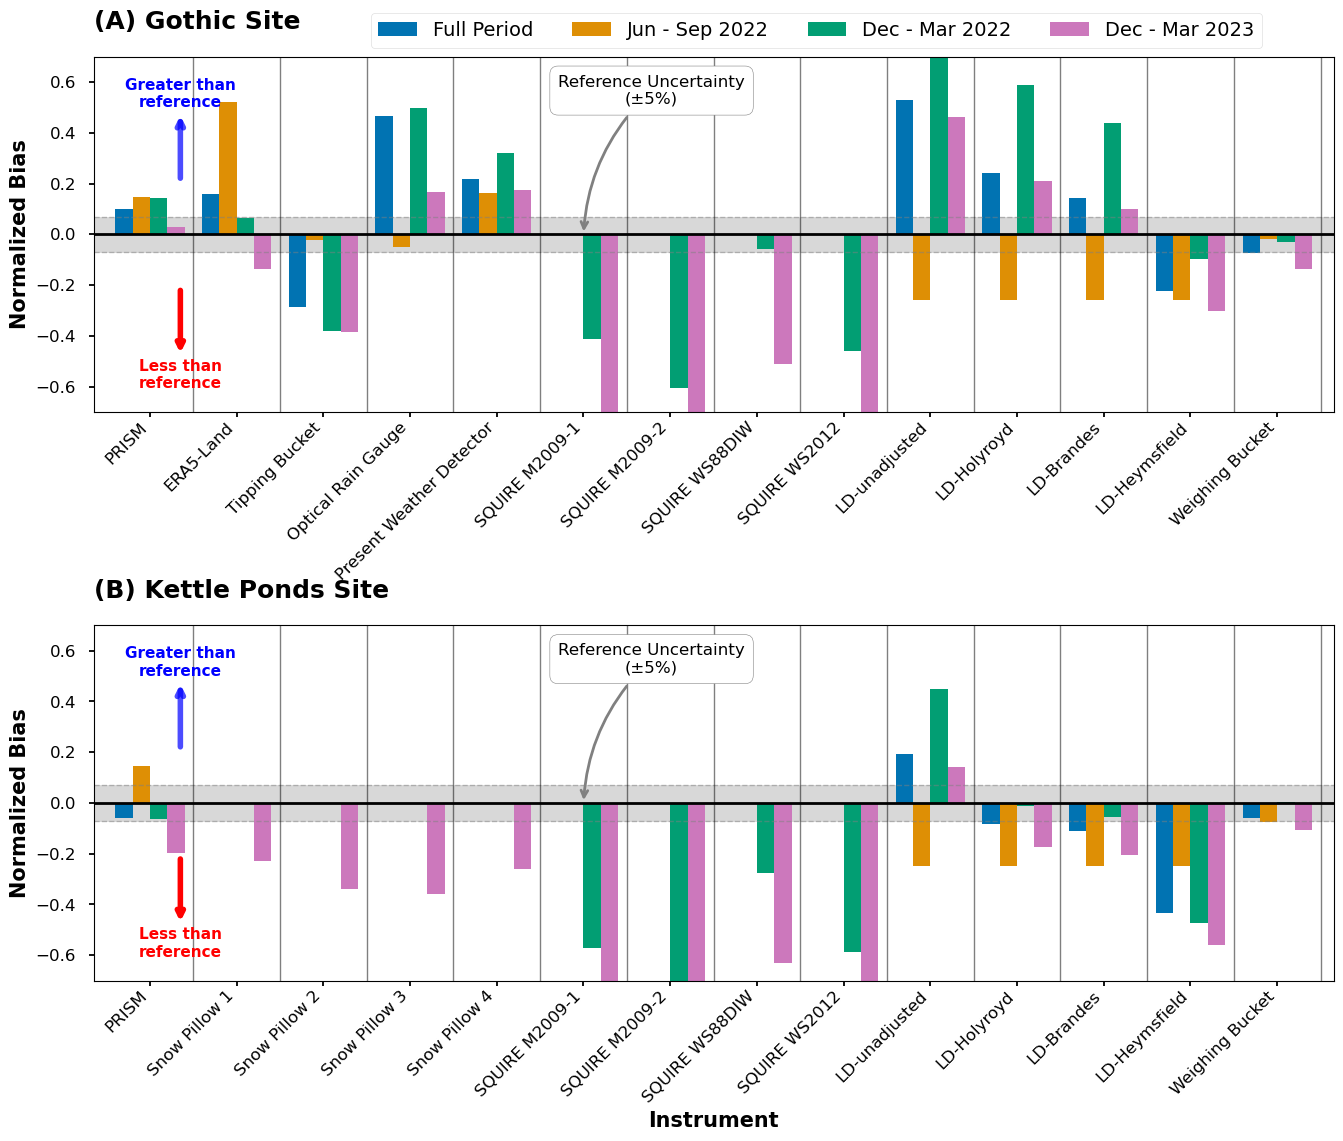

In [37]:
plt.style.use('seaborn-v0_8-talk')
fig, axs = plt.subplots(nrows=2, figsize=(16, 12), gridspec_kw={'hspace': 0.6})

# Colorblind-friendly palette (Wong 2011 palette)
colorblind_colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC']

gt_normalized_bias_renamed_df[cols_to_keep].loc[gt_order].plot(kind='bar', ax=axs[0], width=0.8, color=colorblind_colors)
axs[0].set_title('(A) Gothic Site', fontsize=18, pad=20, weight='bold', loc='left')
axs[0].set_ylabel('Normalized Bias', fontsize=15, weight='bold')
axs[0].set_xlabel('')
axs[0].legend(loc='upper right', ncol=4, bbox_to_anchor=(0.95, 1.15), fontsize=14)
# Don't add legend to first axis, will add shared legend below

kp_normalized_bias_renamed_df[cols_to_keep].loc[kp_order].plot(kind='bar', ax=axs[1], width=0.8, legend=False, color=colorblind_colors)
axs[1].set_title('(B) Kettle Ponds Site', fontsize=18, pad=20, weight='bold', loc='left')
axs[1].set_ylabel('Normalized Bias', fontsize=15, weight='bold')
axs[1].set_xlabel('Instrument', fontsize=15, weight='bold')

for ax in axs:
    # add shading between -0.07 and 0.07
    ax.axhspan(-0.07, 0.07, color='gray', alpha=0.3, zorder=0)
    # add line at 0
    ax.axhline(0, color='black', lw=2, ls='-', zorder=2)
    ax.set_axisbelow(True)
    
    ax.set_ylim(-0.7, 0.7)
    # Rotate x-axis labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    ax.tick_params(axis='x', labelsize=12, pad=2)  # pad controls distance between label and tick
    ax.tick_params(axis='y', labelsize=12)
    
    # Add horizontal lines at reference bounds
    ax.axhline(0.07, color='gray', lw=1, ls='--', alpha=0.5, zorder=1)
    ax.axhline(-0.07, color='gray', lw=1, ls='--', alpha=0.5, zorder=1)
    
    # Add annotation pointing to reference uncertainty band
    ax.annotate('Reference Uncertainty\n(±5%)', 
                xy=(5, 0), xycoords='data',
                xytext=(0.45, 0.95), textcoords='axes fraction',
                fontsize=12, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='gray', lw=2), zorder=50)
    
    # Add arrows indicating direction of bias
    # Blue arrow pointing up (greater than reference)
    ax.annotate('Greater than\nreference', 
                xy=(0.07, 0.65), xycoords='axes fraction',
                xytext=(0.07, 0.85), textcoords='axes fraction',
                fontsize=11, ha='center', va='bottom', color='blue', weight='bold',
                arrowprops=dict(arrowstyle='<-', color='blue', lw=4, alpha=0.7), zorder=50)
    
    # Red arrow pointing down (less than reference)
    ax.annotate('Less than\nreference', 
                xy=(0.07, 0.35), xycoords='axes fraction',
                xytext=(0.07, 0.15), textcoords='axes fraction',
                fontsize=11, ha='center', va='top', color='red', weight='bold',
                arrowprops=dict(arrowstyle='<-', color='red', lw=4), zorder=50)

# Add vertical separators between each instrument
# Gothic site - 14 instruments, so 13 separators
for sep_pos in np.arange(0.5, len(gt_order), 1):
    axs[0].axvline(sep_pos, color='k', lw=1, ls='-', alpha=0.5, zorder=3)

# Kettle Ponds site - 14 instruments, so 13 separators
for sep_pos in np.arange(0.5, len(kp_order), 1):
    axs[1].axvline(sep_pos, color='k', lw=1, ls='-', alpha=0.5, zorder=3)

# Add annotation explaining the shaded region
#'Shaded region indicates reference uncertainty (±5%). Instruments within this zone are considered to perform within acceptable bounds.', 
        
fig.savefig(OUTPUT_DIR / "normalized_bias_comparison_gothic_kettle_ponds.png", bbox_inches='tight')


### RMSE

In [38]:
kp_rmse_df = kp_rmse_df.rename(index=rename_dict)
empty_row = pd.DataFrame(index=[''], data=np.zeros((1, len(gt_rmse_df.columns))), columns=gt_rmse_df.columns)
if len(gt_rmse_df.index) != len(kp_rmse_df.index):
    gt_rmse_df = pd.concat([gt_rmse_df.rename(index=rename_dict), empty_row, ], axis=0).rename(index=rename_dict)


### Plotting RMSE

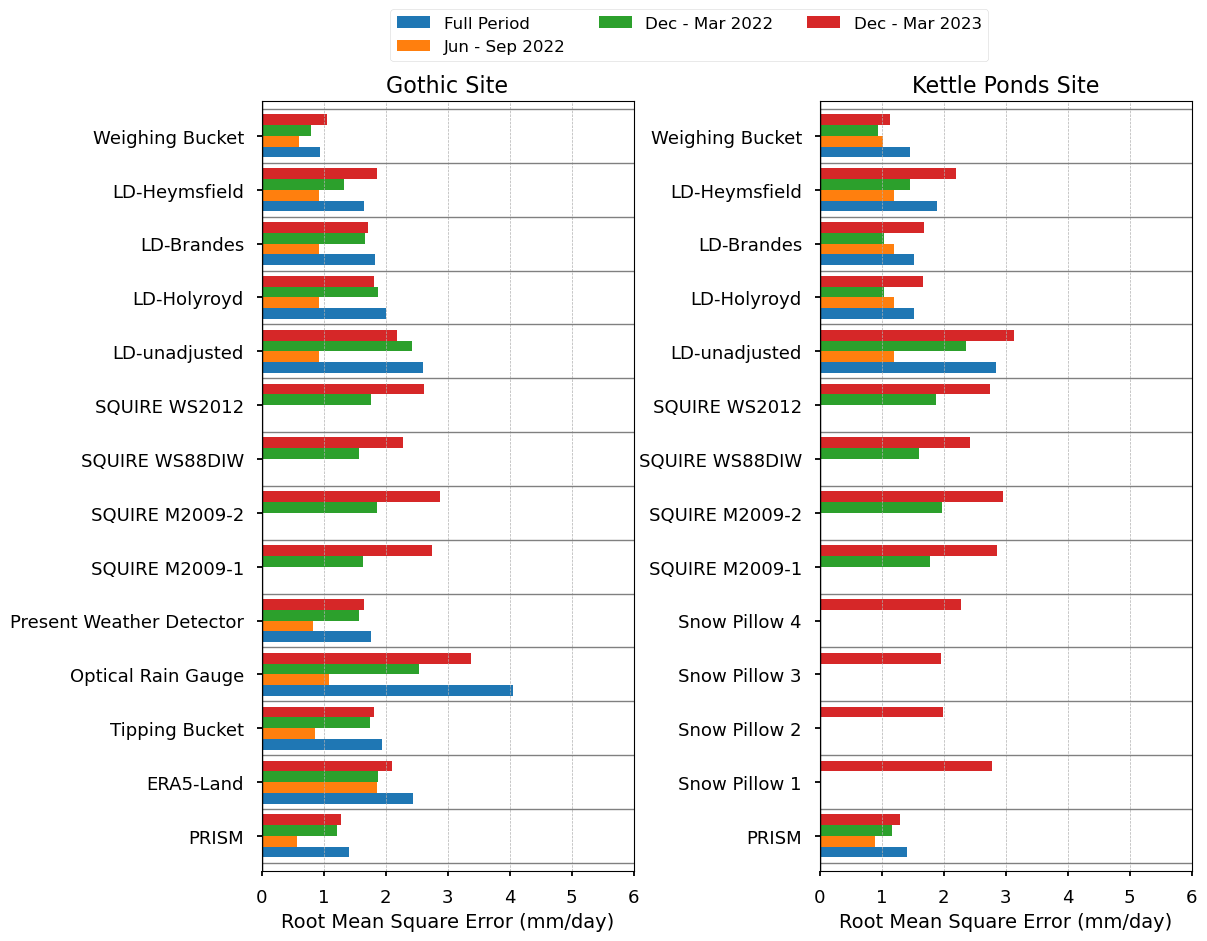

In [39]:
plt.style.use('seaborn-v0_8-talk')
fig, axs = plt.subplots(ncols=2, figsize=(12,10), gridspec_kw={'wspace': 0.5})
gt_rmse_df[cols_to_keep].loc[gt_order].plot(kind='barh', ax=axs[0], width=0.8,)
for i in range(len(gt_rmse_df)):
        axs[0].axhline(i-0.5, color='gray', lw=1, ls='-')

# add titles 
axs[0].set_title('Gothic Site', fontsize=16)
axs[1].set_title('Kettle Ponds Site', fontsize=16)

# add legend
axs[0].legend(bbox_to_anchor=(1.15, 1.13), loc='upper center', ncol=3, fontsize=12)

# also plot the kettle ponds data that match the row names of gt_rmse_df
kp_rmse_df[cols_to_keep].loc[kp_order].plot(kind='barh', ax=axs[1], width=0.8, legend=False)
for i in range(len(kp_rmse_df)):
        axs[1].axhline(i-0.5, color='gray', lw=1, ls='-')
for ax in axs:
    # add line at 0
    ax.axvline(0, color='black', lw=1, ls='-')
    # add gridlines
    ax.xaxis.grid(True, which='major', linestyle='--', linewidth=0.5)

#     for gauge in gt_rmse_df.loc[kp_order].index:
#         if gauge == 'SQuIRE\nWS88DIW':
#             # add text annotation to the right of this bar
#                 y_pos = 3.5
#                 ax.text(0.55, y_pos, 'December - March\nonly for SQuIRE', 
#                         fontsize=12,
#                         color='k',
#                         weight = 'bold', 
#                         va='center', 
#                         ha='left', 
#                         transform=ax.get_yaxis_transform())
#     for gauge in kp_rmse_df.loc[kp_order].index:
#         if gauge == 'SP 3':
                # y_pos = 11.5
                # axs[1].text(0.50, y_pos, 'December - March\nonly for snow pillows', 
                #         fontsize=12,
                #         color='k',
                #         weight = 'bold', 
                #         va='center', 
                #         ha='left', 
                #         transform=axs[1].get_yaxis_transform())
    
    ax.set_xlabel('Root Mean Square Error (mm/day)', fontsize=14)
    ax.set_xlim(0.,6)
fig.savefig(OUTPUT_DIR / "rmse_comparison_gothic_kettle_ponds.png", bbox_inches='tight')

## Taylor Diagrams

In [40]:
ANALYSIS_TYPE = 'all'  # options: 'all', 'rain', 'snow'

### Gothic

In [41]:
SITE = "gothic"
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None if not seasonal analysis
original_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in original_ds.data_vars if 'qc' in var]
gothic_ds_no_qc = original_ds.drop_vars(qc_vars)

# get time extents for all variables
time_slice = get_relevant_dates(gothic_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(gothic_ds_no_qc[GRIDDED_VARS], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(gothic_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(gothic_ds_no_qc[GRIDDED_VARS].sel(time=gridded_time_slice).resample(time='1D', offset='8h').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_all_data_prcp_taylor.png


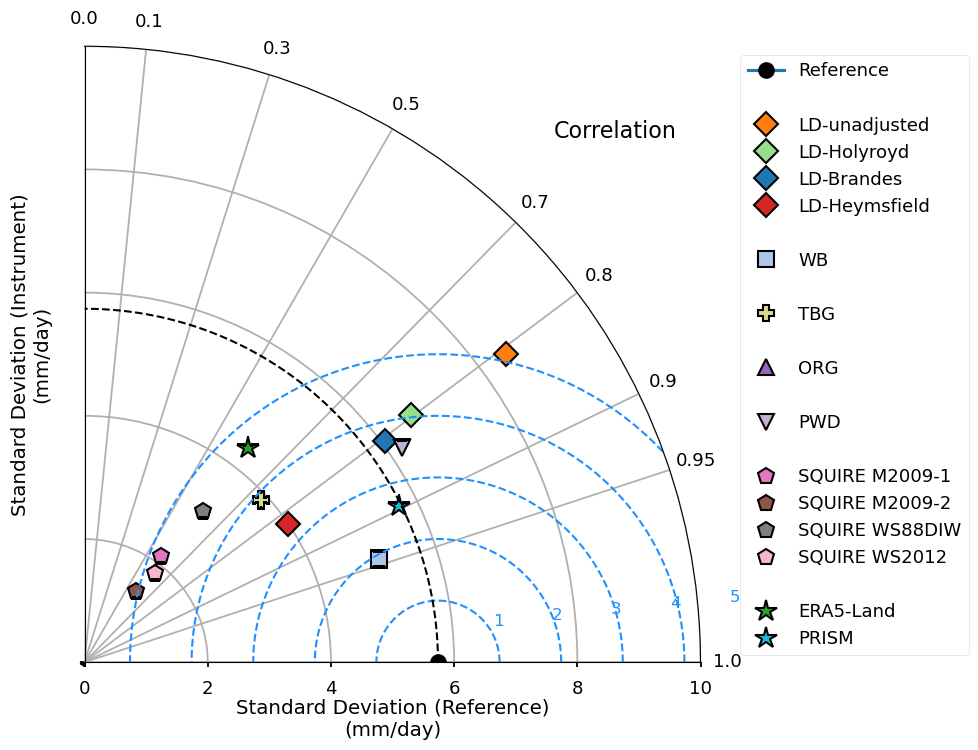

In [42]:
fig = plot_taylor_diagram(ds, ds_gridded, benchmark='billy_barr_precip')

save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='taylor', gridded=False, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [43]:
SITE = "kettle_ponds"

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)
qc_vars = [var for var in original_ds.data_vars if 'qc' in var] + ['precip_type']
kettle_ponds_ds_no_qc = original_ds.drop_vars(qc_vars)

# get time extents for all variables
time_slice = get_relevant_dates(kettle_ponds_ds_no_qc, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(kettle_ponds_ds_no_qc[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)
# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(kettle_ponds_ds_no_qc[gridded_vars].sel(time=gridded_time_slice).resample(time='1D', offset='8h').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_taylor.png


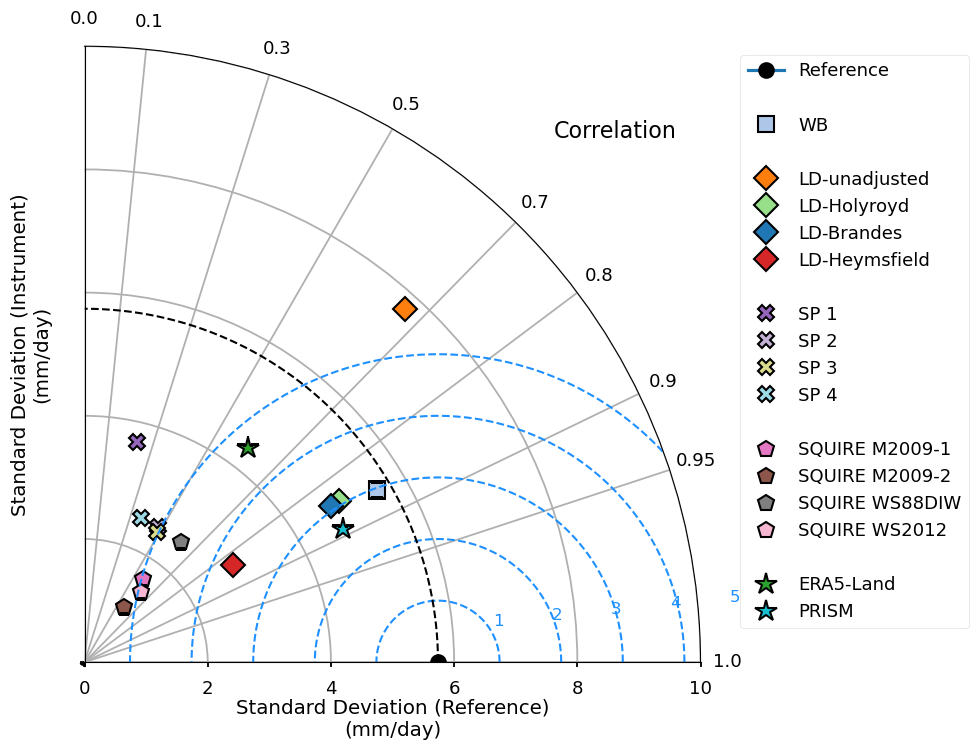

In [44]:
fig = plot_taylor_diagram(ds, ds_gridded, benchmark='billy_barr_precip')
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='taylor', gridded=False, output_dir=OUTPUT_DIR)